# Customer Segmentation using RFM Analysis & K-Means Clustering

## Project Objective

Customer segmentation is a powerful marketing technique used by businesses to divide their customers into different groups based on their purchasing behavior.

The main objective of this project is to segment customers based on their transaction behavior using **RFM Analysis (Recency, Frequency, Monetary)** and apply **K-Means Clustering** to identify different types of customers.

This helps businesses to:

- Identify loyal customers
- Find high value customers
- Detect inactive customers
- Improve targeted marketing strategies
- Increase customer retention

Machine learning clustering techniques allow companies to automatically group customers based on purchasing patterns.

In [22]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

| Library    | Purpose                     |
| ---------- | --------------------------- |
| pandas     | Data manipulation           |
| numpy      | Numerical operations        |
| matplotlib | Data visualization          |
| seaborn    | Statistical visualization   |
| sklearn    | Machine learning algorithms |


## Loading Dataset

The dataset used in this project contains transaction records from an online retail store.

Main columns include:

- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country

In [23]:
df = pd.read_excel(r"C:\Users\Chinnarajan M\OneDrive\Documents\Chinna projects\Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df.shape

(541909, 8)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [26]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


The dataset contains more than **500,000 transaction records**.

Each row represents a product purchased by a customer.

Important fields for RFM analysis:

- CustomerID
- InvoiceDate
- Quantity
- UnitPrice

Before performing RFM analysis, we need to clean the dataset.

Steps performed:

1. Remove missing CustomerID
2. Remove cancelled transactions
3. Remove negative quantities
4. Create a new column called TotalPrice

In [27]:
# Remove missing customer ID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

# Remove negative quantity
df = df[df['Quantity'] > 0]

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [28]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## RFM Analysis

RFM stands for:

Recency → How recently a customer purchased  
Frequency → How often a customer purchases  
Monetary → How much money the customer spends

These three metrics help identify valuable customers.

In [29]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

RFM = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

RFM.columns = ['Recency', 'Frequency', 'Monetary']

RFM.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


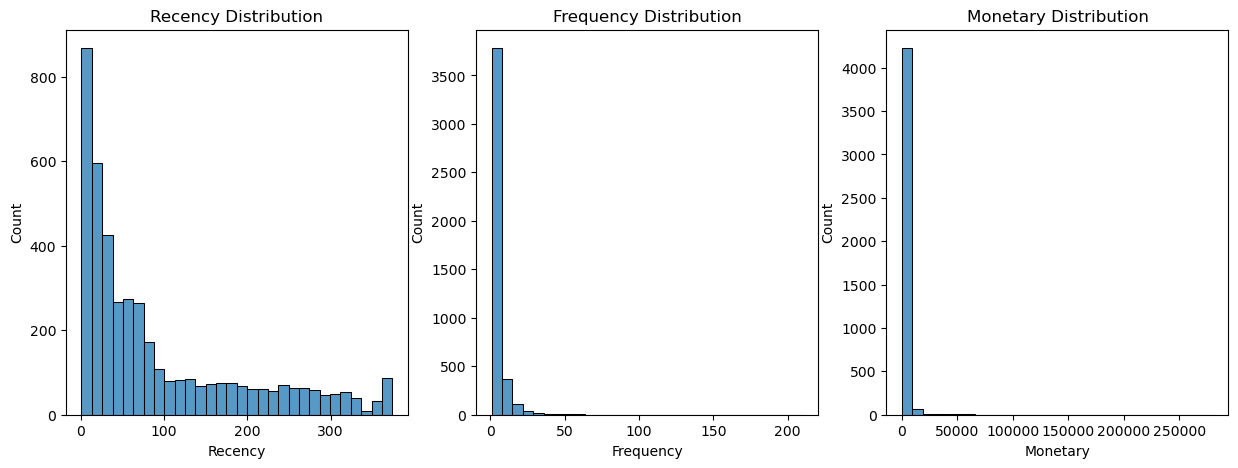

In [30]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(RFM['Recency'],bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.histplot(RFM['Frequency'],bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.histplot(RFM['Monetary'],bins=30)
plt.title("Monetary Distribution")

plt.show()

The distributions show how customers behave:

Recency → lower value means recent purchase  
Frequency → higher value means repeat purchases  
Monetary → higher value means high spending customers

Machine learning algorithms like K-Means are sensitive to scale.

Therefore we standardize the RFM values using StandardScaler.

In [31]:
scaler = StandardScaler()

RFM_scaled = scaler.fit_transform(RFM)

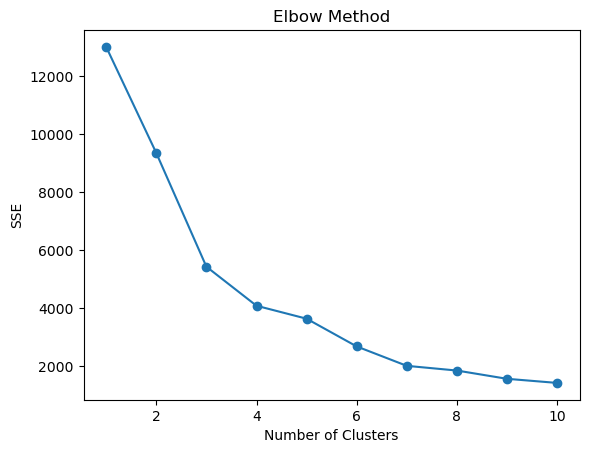

In [32]:
# Find Optimal Clusters (Elbow Method)

sse = [] # Sum of Squared Errors

for k in range(1,11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(RFM_scaled)
    
    sse.append(kmeans.inertia_)

plt.plot(range(1,11), sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

The Elbow Method helps determine the optimal number of clusters.

The point where the curve bends is considered the best number of clusters.

In [33]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=42)

RFM['Cluster'] = kmeans.fit_predict(RFM_scaled)

RFM.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


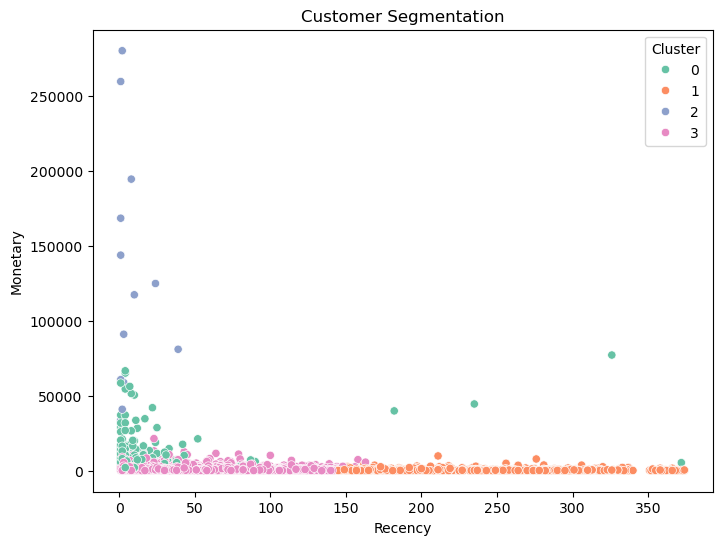

In [34]:
# Cluster Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=RFM['Recency'],
    y=RFM['Monetary'],
    hue=RFM['Cluster'],
    palette='Set2'
)

plt.title("Customer Segmentation")
plt.show()

In [35]:
# Cluster Analysis
cluster_summary = RFM.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.692308,127338.313846
3,43.910580,3.655748,1349.698298


# Customer Segment Interpretation

| Cluster | Customer Type        |
| ------- | -------------------- |
| 0       | Loyal Customers      |
| 1       | At Risk Customers    |
| 2       | High Value Customers |
| 3       | Potential Customers  |



## Business Insights

Cluster 0 – Loyal Customers
These customers purchase frequently and spend good money. They should be rewarded with loyalty programs.

Cluster 1 – At Risk Customers
Customers who have not purchased recently. Re-engagement campaigns can help win them back.

Cluster 2 – High Value Customers
Customers with high spending. Businesses should focus on premium marketing strategies.

Cluster 3 – Potential Customers
Customers who purchase occasionally. Target them with personalized promotions.



## Conclusion

In this project, we implemented **Customer Segmentation using RFM Analysis and K-Means Clustering**.

Key achievements:

- Cleaned and prepared large transaction dataset
- Engineered RFM features
- Standardized features for clustering
- Applied K-Means clustering algorithm
- Identified meaningful customer segments

The segmentation helps businesses understand customer behavior and build better marketing strategies.

This project demonstrates the practical application of **unsupervised machine learning in business analytics**.